# Direction Model V2 — Curated Features + Higher Vol Threshold (Cross-Pair)

**Goal:** Improve direction accuracy from 52-53% by refining the training signal.

**Two improvements over V1:**
1. **Curated features** — drop pure volatility features that only help the vol model, keep direction-relevant features
2. **Top 33% vol threshold** — train only on the most volatile third of hours (cleaner directional signal)

**Kept from V1:** Single pooled cross-pair model (more data > per-pair specialization)

**Architecture:**
- Vol model: unchanged, reuse `vol_model.joblib` from notebook 01
- Direction model: 1 LightGBM classifier trained on all 7 pairs pooled, high-vol rows only

**Leakage prevention:**
- TRAIN_END = '2024-06-30' — strict temporal split
- Vol threshold = P67 of |return| on full training data
- Walk-forward CV within training set only
- No test-set statistics used anywhere in training

In [14]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import accuracy_score

FEATURES_DIR = Path('../backend/data/features')
MODELS_DIR   = Path('../backend/models_4')
DIR_V2_DIR   = MODELS_DIR / 'dir_v2'
DIR_V2_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_END = '2024-06-30'
TARGET_COL = 'label_1H'

# Top 33% = rows where |return| > P67 of |return| (training data only)
VOL_TRAIN_PERCENTILE = 67

print('Ready.')
print(f'Training cutoff: {TRAIN_END}')
print(f'Vol training filter: top {100 - VOL_TRAIN_PERCENTILE}% hours')

Ready.
Training cutoff: 2024-06-30
Vol training filter: top 33% hours


## 1. Load Data & Define Direction-Curated Features

In [15]:
df = pd.read_parquet(FEATURES_DIR / 'all_pairs_features_labels.parquet')

label_cols = [c for c in df.columns if c.startswith('label_')]

# ── Direction-curated feature set ──
# DROP: pure volatility features (vol model already handles this)
# These measure HOW MUCH the market moves, not WHERE it goes
vol_only_prefixes = [
    'rvol_',       # realized volatility
    'vol_zscore_', # volatility z-scores
    'vol_trend_',  # vol trend
    'vol_regime_', # vol regime
    'vol_sma_ratio_', # vol vs sma
    'vol_change_',    # vol changes
    'atr_',        # average true range (pure vol)
    'bb_width_',   # bollinger band width (vol measure)
    'hl_range_',   # high-low range (vol)
    'range_ratio_', # range ratios (vol)
]

# Also drop: vol_expansion, asian_range, prev_session_range (pure vol)
vol_only_exact = ['vol_expansion', 'asian_range', 'prev_session_range']

all_feature_cols = [c for c in df.columns if c not in label_cols + ['pair']]

dir_feature_cols = []
dropped = []
for c in all_feature_cols:
    is_vol = any(c.startswith(p) for p in vol_only_prefixes) or c in vol_only_exact
    if is_vol:
        dropped.append(c)
    else:
        dir_feature_cols.append(c)

print(f'Total features available: {len(all_feature_cols)}')
print(f'Dropped (pure vol):       {len(dropped)}')
print(f'Direction features kept:   {len(dir_feature_cols)}')
print(f'\nDropped features:')
for c in sorted(dropped):
    print(f'  {c}')

# Targets
df['abs_return'] = df[TARGET_COL].abs()
df['direction']  = (df[TARGET_COL] > 0).astype(int)  # 1=UP, 0=DOWN

# Split
df_train = df[df.index <= TRAIN_END].copy()
df_test  = df[df.index > TRAIN_END].copy()

pairs = sorted(df['pair'].unique())
print(f'\nTrain: {len(df_train):,} rows ({df_train.index.min().date()} to {df_train.index.max().date()})')
print(f'Test:  {len(df_test):,} rows ({df_test.index.min().date()} to {df_test.index.max().date()})')
print(f'Pairs: {pairs}')

Total features available: 314
Dropped (pure vol):       76
Direction features kept:   238

Dropped features:
  asian_range
  atr_14_norm_1H
  atr_14_norm_4H
  atr_28_norm_15m
  atr_28_norm_1D
  atr_28_norm_4H
  atr_ratio_15m
  atr_ratio_1D
  atr_ratio_1H
  atr_ratio_4H
  atr_ratio_5m
  atr_zscore_15m
  atr_zscore_1D
  atr_zscore_1H
  atr_zscore_4H
  atr_zscore_5m
  bb_width_15m
  bb_width_1D
  bb_width_1H
  bb_width_4H
  bb_width_5m
  hl_range_15m
  hl_range_1D
  hl_range_1H
  hl_range_4H
  prev_session_range
  range_ratio_3_15m
  range_ratio_3_1D
  range_ratio_3_1H
  range_ratio_3_4H
  range_ratio_3_5m
  rvol_12_15m
  rvol_12_1D
  rvol_12_1H
  rvol_12_4H
  rvol_12_5m
  rvol_24_15m
  rvol_24_1D
  rvol_24_1H
  rvol_24_4H
  rvol_24_5m
  rvol_48_15m
  rvol_48_1D
  rvol_48_1H
  rvol_48_4H
  rvol_48_5m
  rvol_ratio_15m
  rvol_ratio_1D
  rvol_ratio_1H
  rvol_ratio_4H
  rvol_ratio_5m
  vol_change_6_15m
  vol_change_6_1D
  vol_change_6_1H
  vol_change_6_4H
  vol_change_6_5m
  vol_expansion
  v

## 2. Vol Threshold for Training Row Selection

In [16]:
# Compute vol threshold from TRAINING data only (all pairs pooled)
valid_mask = df_train[TARGET_COL].notna()
train_abs_return = df_train.loc[valid_mask, 'abs_return']
vol_threshold = np.percentile(train_abs_return, VOL_TRAIN_PERCENTILE)

print(f'Vol threshold (P{VOL_TRAIN_PERCENTILE} of |return| on TRAINING data): {vol_threshold:.6f}')
print(f'Total valid training rows: {valid_mask.sum():,}')

high_vol_mask = valid_mask & (df_train['abs_return'] > vol_threshold)
n_high = high_vol_mask.sum()
print(f'High-vol training rows:    {n_high:,} ({n_high/valid_mask.sum()*100:.1f}%)')

# Per-pair breakdown
print(f'\nPer-pair high-vol breakdown:')
print(f'{"Pair":<10} {"Total":>10} {"High-vol":>10} {"Pct":>6} {"UP%":>6}')
print('-' * 46)
for pair in pairs:
    pm = (df_train['pair'] == pair) & valid_mask
    hvm = pm & (df_train['abs_return'] > vol_threshold)
    up_pct = df_train.loc[hvm, 'direction'].mean()
    print(f'{pair:<10} {pm.sum():>10,} {hvm.sum():>10,} {hvm.sum()/pm.sum()*100:>5.1f}% {up_pct:>5.1%}')

print(f'\nThis threshold is FIXED from training data.')

Vol threshold (P67 of |return| on TRAINING data): 0.000841
Total valid training rows: 622,579
High-vol training rows:    205,451 (33.0%)

Per-pair high-vol breakdown:
Pair            Total   High-vol    Pct    UP%
----------------------------------------------
AUDUSD         89,734     37,249  41.5% 50.0%
EURUSD         89,395     25,052  28.0% 49.6%
GBPUSD         89,226     26,715  29.9% 50.0%
NZDUSD         88,375     39,333  44.5% 50.2%
USDCAD         88,804     24,841  28.0% 50.2%
USDCHF         88,351     26,361  29.8% 50.3%
USDJPY         88,694     25,900  29.2% 50.9%

This threshold is FIXED from training data.


## 3. Walk-Forward CV — Pooled Cross-Pair Direction Model

In [17]:
def walk_forward_splits(n, n_splits=5, test_ratio=0.1):
    """Expanding window walk-forward splits."""
    test_size = int(n * test_ratio)
    splits = []
    for i in range(n_splits):
        test_start = int(n * 0.5) + i * (int(n * 0.5) // n_splits)
        test_end   = test_start + test_size
        if test_end > n:
            break
        splits.append((list(range(0, test_start)), list(range(test_start, test_end))))
    return splits


DIR_PARAMS = {
    'objective':         'binary',
    'metric':            'binary_logloss',
    'boosting_type':     'gbdt',
    'n_estimators':      5000,
    'learning_rate':     0.02,
    'num_leaves':        64,       # same as V1
    'max_depth':         6,        # same as V1
    'min_child_samples': 50,       # same as V1 (plenty of data in pooled model)
    'feature_fraction':  0.7,      # same as V1
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'reg_alpha':         0.1,      # same as V1
    'reg_lambda':        0.1,      # same as V1
    'random_state':      42,
    'n_jobs':            -1,
    'verbose':           -1,
    'device':            'gpu',
}

# Prepare pooled high-vol training data
X_train_all = df_train[dir_feature_cols].ffill().fillna(0)
y_dir_all = df_train['direction']

X_dir = X_train_all[high_vol_mask]
y_dir = y_dir_all[high_vol_mask]

print(f'Direction Model V2 — Pooled Cross-Pair')
print(f'Target: UP(1) / DOWN(0)')
print(f'Training rows: {len(X_dir):,} (top {100-VOL_TRAIN_PERCENTILE}% vol, all pairs pooled)')
print(f'Features: {len(dir_feature_cols)} (direction-curated)')
print(f'Direction balance: {y_dir.mean():.3f} UP')

# Walk-forward CV
splits = walk_forward_splits(len(X_dir))
oof_preds = np.full(len(X_dir), np.nan)
fold_accs = []
fold_iters = []

for fold, (tr_idx, te_idx) in enumerate(splits):
    X_tr, y_tr = X_dir.iloc[tr_idx], y_dir.iloc[tr_idx]
    X_te, y_te = X_dir.iloc[te_idx], y_dir.iloc[te_idx]
    
    model = lgb.LGBMClassifier(**DIR_PARAMS)
    model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    
    probs = model.predict_proba(X_te)[:, 1]
    preds = (probs > 0.5).astype(int)
    oof_preds[te_idx] = probs
    
    acc = accuracy_score(y_te, preds)
    fold_accs.append(acc)
    fold_iters.append(model.best_iteration_)
    print(f'  Fold {fold+1}: Acc={acc:.4f} ({acc*100:.1f}%) | best_iter={model.best_iteration_}')

print(f'\nCV Accuracy: {np.mean(fold_accs)*100:.1f}% +/- {np.std(fold_accs)*100:.1f}%')
print(f'Best iters: {fold_iters}')

# Accuracy by confidence bucket
valid_oof = ~np.isnan(oof_preds)
y_oof = y_dir.values[valid_oof]
p_oof = oof_preds[valid_oof]
conf = np.abs(p_oof - 0.5)
conf_bins = pd.qcut(conf, 5, labels=['Low', 'Q2', 'Q3', 'Q4', 'High'], duplicates='drop')
pred_labels = (p_oof > 0.5).astype(int)
acc_by_conf = pd.DataFrame({'conf_bin': conf_bins, 'correct': (pred_labels == y_oof)}).groupby('conf_bin')['correct']
print(f'\nAccuracy by confidence quintile:')
for name, grp in acc_by_conf:
    print(f'  {name}: {grp.mean():.3f} ({grp.mean()*100:.1f}%) — {len(grp):,} samples')

Direction Model V2 — Pooled Cross-Pair
Target: UP(1) / DOWN(0)
Training rows: 205,451 (top 33% vol, all pairs pooled)
Features: 238 (direction-curated)
Direction balance: 0.501 UP
  Fold 1: Acc=0.5465 (54.7%) | best_iter=417
  Fold 2: Acc=0.5344 (53.4%) | best_iter=201
  Fold 3: Acc=0.5411 (54.1%) | best_iter=286
  Fold 4: Acc=0.5481 (54.8%) | best_iter=463
  Fold 5: Acc=0.5381 (53.8%) | best_iter=353

CV Accuracy: 54.2% +/- 0.5%
Best iters: [417, 201, 286, 463, 353]

Accuracy by confidence quintile:
  Low: 0.509 (50.9%) — 20,545 samples
  Q2: 0.514 (51.4%) — 20,545 samples
  Q3: 0.532 (53.2%) — 20,545 samples
  Q4: 0.538 (53.8%) — 20,545 samples
  High: 0.615 (61.5%) — 20,545 samples


## 4. Train Final Model

In [18]:
# Train final model on ALL high-vol training data (all pairs pooled)
avg_iter = max(50, int(np.mean(fold_iters)))
print(f'Training final model with {avg_iter} iterations on {len(X_dir):,} high-vol rows (all pairs)...')

final_model = lgb.LGBMClassifier(**{**DIR_PARAMS, 'n_estimators': avg_iter})
final_model.fit(X_dir, y_dir)

# Save model bundle
bundle = {
    'model': final_model,
    'type': 'direction_v2_pooled',
    'target': 'UP/DOWN on high-vol hours',
    'feature_cols': dir_feature_cols,
    'vol_threshold': vol_threshold,
    'vol_train_percentile': VOL_TRAIN_PERCENTILE,
    'train_end': TRAIN_END,
    'cv_accuracy': np.mean(fold_accs),
    'cv_std': np.std(fold_accs),
    'avg_iter': avg_iter,
    'params': DIR_PARAMS,
    'n_features_dropped': len(dropped),
}

save_path = DIR_V2_DIR / 'dir_v2_pooled.joblib'
joblib.dump(bundle, save_path)
print(f'Saved: {save_path}')
print(f'Size: {save_path.stat().st_size / 1024 / 1024:.1f} MB')

Training final model with 344 iterations on 205,451 high-vol rows (all pairs)...
Saved: ..\backend\models_4\dir_v2\dir_v2_pooled.joblib
Size: 1.9 MB


## 5. Evaluate on UNSEEN Test Set

In [19]:
# Load vol model for combined evaluation
vol_bundle = joblib.load(MODELS_DIR / 'vol_model.joblib')
vol_model = vol_bundle['model']
vol_feature_cols = vol_bundle['feature_cols']
vol_pct = vol_bundle['vol_percentiles']  # from training data

# Load V1 direction model for comparison
dir_v1_bundle = joblib.load(MODELS_DIR / 'dir_model.joblib')
dir_v1_model = dir_v1_bundle['model']
v1_feature_cols = dir_v1_bundle['feature_cols']

# Prepare test data
valid_test = df_test[TARGET_COL].notna()
df_test_valid = df_test[valid_test].copy()

# Vol predictions
X_test_vol = df_test_valid[vol_feature_cols].ffill().fillna(0)
vol_preds = vol_model.predict(X_test_vol)

# V2 direction predictions (curated features)
X_test_v2 = df_test_valid[dir_feature_cols].ffill().fillna(0)
v2_probs = final_model.predict_proba(X_test_v2)[:, 1]

# V1 direction predictions (all features)
X_test_v1 = df_test_valid[v1_feature_cols].ffill().fillna(0)
v1_probs = dir_v1_model.predict_proba(X_test_v1)[:, 1]

# Build results DataFrame
results = pd.DataFrame({
    'actual_return': df_test_valid[TARGET_COL].values,
    'pred_vol': vol_preds,
    # V2
    'v2_p_up': v2_probs,
    'v2_dir': np.where(v2_probs > 0.5, 1, -1),
    # V1
    'v1_p_up': v1_probs,
    'v1_dir': np.where(v1_probs > 0.5, 1, -1),
    # Actual
    'actual_dir': np.where(df_test_valid[TARGET_COL].values > 0, 1, -1),
    'pair': df_test_valid['pair'].values,
}, index=df_test_valid.index)

# V2 metrics
results['v2_correct'] = (results['v2_dir'] == results['actual_dir'])
results['v2_pnl'] = results['v2_dir'] * results['actual_return']
results['v2_conf'] = results['v2_p_up'].clip(0, 1)
results['v2_conf'] = results['v2_conf'].where(results['v2_dir'] == 1, 1 - results['v2_conf'])

# V1 metrics
results['v1_correct'] = (results['v1_dir'] == results['actual_dir'])
results['v1_pnl'] = results['v1_dir'] * results['actual_return']
results['v1_conf'] = results['v1_p_up'].clip(0, 1)
results['v1_conf'] = results['v1_conf'].where(results['v1_dir'] == 1, 1 - results['v1_conf'])

print(f'Test set: {len(results):,} rows ({results.index.min().date()} to {results.index.max().date()})')
print(f'Vol preds — mean: {vol_preds.mean():.6f}')
print(f'V2 dir probs — mean: {v2_probs.mean():.3f}')
print(f'V1 dir probs — mean: {v1_probs.mean():.3f}')

Test set: 62,532 rows (2024-07-01 to 2025-12-19)
Vol preds — mean: 0.000810
V2 dir probs — mean: 0.489
V1 dir probs — mean: 0.493


In [20]:
# ── V2 vs V1 at different vol filter thresholds ──
vol_thresholds = {
    'All hours': 0,
    'Top 75%': vol_pct[25],
    'Top 50%': vol_pct[50],
    'Top 33%': vol_pct[67],
    'Top 20%': vol_pct[80],
    'Top 10%': vol_pct[90],
}

print(f'{"Filter":<20} {"Trades":>8} | {"V2 Acc":>8} {"V2 PnL":>10} {"V2 Shrp":>8} | {"V1 Acc":>8} {"V1 PnL":>10} {"V1 Shrp":>8} | {"dAcc":>6}')
print('-' * 105)

for name, thresh in vol_thresholds.items():
    mask = results['pred_vol'] > thresh
    if mask.sum() < 100:
        continue
    s = results[mask]
    
    v2_acc = s['v2_correct'].mean()
    v1_acc = s['v1_correct'].mean()
    v2_pnl = s['v2_pnl'].sum()
    v1_pnl = s['v1_pnl'].sum()
    v2_sh = (s['v2_pnl'].mean() / s['v2_pnl'].std()) * np.sqrt(252*24) if s['v2_pnl'].std() > 0 else 0
    v1_sh = (s['v1_pnl'].mean() / s['v1_pnl'].std()) * np.sqrt(252*24) if s['v1_pnl'].std() > 0 else 0
    delta = (v2_acc - v1_acc) * 100
    
    print(f'{name:<20} {mask.sum():>8,} | {v2_acc:>7.1%} {v2_pnl:>10.4f} {v2_sh:>8.2f} | {v1_acc:>7.1%} {v1_pnl:>10.4f} {v1_sh:>8.2f} | {delta:>+5.1f}pp')

# With confidence filter
print(f'\n--- With confidence >= 55% ---')
print(f'{"Filter":<20} {"Trades":>8} | {"V2 Acc":>8} {"V2 PnL":>10} {"V2 Shrp":>8} | {"V1 Acc":>8} {"V1 PnL":>10} {"V1 Shrp":>8} | {"dAcc":>6}')
print('-' * 105)

for name, thresh in vol_thresholds.items():
    v2_mask = (results['pred_vol'] > thresh) & (results['v2_conf'] >= 0.55)
    v1_mask = (results['pred_vol'] > thresh) & (results['v1_conf'] >= 0.55)
    if v2_mask.sum() < 50 or v1_mask.sum() < 50:
        continue
    
    s2 = results[v2_mask]
    s1 = results[v1_mask]
    
    v2_acc = s2['v2_correct'].mean()
    v1_acc = s1['v1_correct'].mean()
    v2_pnl = s2['v2_pnl'].sum()
    v1_pnl = s1['v1_pnl'].sum()
    v2_sh = (s2['v2_pnl'].mean() / s2['v2_pnl'].std()) * np.sqrt(252*24) if s2['v2_pnl'].std() > 0 else 0
    v1_sh = (s1['v1_pnl'].mean() / s1['v1_pnl'].std()) * np.sqrt(252*24) if s1['v1_pnl'].std() > 0 else 0
    delta = (v2_acc - v1_acc) * 100
    
    print(f'{name:<20} {v2_mask.sum():>5}/{v1_mask.sum():<5}| {v2_acc:>7.1%} {v2_pnl:>10.4f} {v2_sh:>8.2f} | {v1_acc:>7.1%} {v1_pnl:>10.4f} {v1_sh:>8.2f} | {delta:>+5.1f}pp')

Filter                 Trades |   V2 Acc     V2 PnL  V2 Shrp |   V1 Acc     V1 PnL  V1 Shrp |   dAcc
---------------------------------------------------------------------------------------------------------
All hours              62,531 |   52.7%     6.7751     2.85 |   53.2%     6.8077     2.86 |  -0.5pp
Top 75%                47,378 |   52.4%     6.2123     3.01 |   52.6%     6.1597     2.99 |  -0.2pp
Top 50%                30,334 |   52.0%     5.2769     3.24 |   52.1%     5.2084     3.19 |  -0.1pp
Top 33%                18,196 |   52.1%     4.6496     3.74 |   52.2%     4.6785     3.76 |  -0.2pp
Top 20%                 9,930 |   52.5%     4.3707     4.83 |   52.5%     4.4750     4.95 |  +0.0pp
Top 10%                 4,258 |   53.1%     3.4904     6.43 |   53.1%     3.7008     6.82 |  +0.0pp

--- With confidence >= 55% ---
Filter                 Trades |   V2 Acc     V2 PnL  V2 Shrp |   V1 Acc     V1 PnL  V1 Shrp |   dAcc
------------------------------------------------------------

In [21]:
# ── Per-pair breakdown at Top 33% vol filter ──
vol_thresh_eval = vol_pct[67]
filtered = results[results['pred_vol'] > vol_thresh_eval]

print(f'Per-pair at Top 33% vol (threshold from training: {vol_thresh_eval:.6f}):')
print(f'{"Pair":<10} {"Trades":>7} | {"V2 Acc":>8} {"V2 PnL":>10} {"V2 Shrp":>8} | {"V1 Acc":>8} {"V1 PnL":>10} {"V1 Shrp":>8} | {"dAcc":>6}')
print('-' * 95)

for pair in pairs:
    p = filtered[filtered['pair'] == pair]
    if len(p) < 50:
        continue
    v2_acc = p['v2_correct'].mean()
    v1_acc = p['v1_correct'].mean()
    v2_pnl = p['v2_pnl'].sum()
    v1_pnl = p['v1_pnl'].sum()
    v2_sh = (p['v2_pnl'].mean() / p['v2_pnl'].std()) * np.sqrt(252*24) if p['v2_pnl'].std() > 0 else 0
    v1_sh = (p['v1_pnl'].mean() / p['v1_pnl'].std()) * np.sqrt(252*24) if p['v1_pnl'].std() > 0 else 0
    delta = (v2_acc - v1_acc) * 100
    print(f'{pair:<10} {len(p):>7,} | {v2_acc:>7.1%} {v2_pnl:>10.4f} {v2_sh:>8.2f} | {v1_acc:>7.1%} {v1_pnl:>10.4f} {v1_sh:>8.2f} | {delta:>+5.1f}pp')

Per-pair at Top 33% vol (threshold from training: 0.000929):
Pair        Trades |   V2 Acc     V2 PnL  V2 Shrp |   V1 Acc     V1 PnL  V1 Shrp |   dAcc
-----------------------------------------------------------------------------------------------
AUDUSD       3,500 |   52.9%     0.5564     4.43 |   52.6%     0.5456     4.34 |  +0.3pp
EURUSD       1,670 |   50.9%     0.0878     2.29 |   50.5%     0.0120     0.31 |  +0.4pp
GBPUSD       1,501 |   49.1%    -0.0043    -0.07 |   50.6%     0.0577     0.93 |  -1.5pp
NZDUSD       4,500 |   51.4%     1.6723     4.59 |   53.3%     1.9957     5.48 |  -1.8pp
USDCAD       1,107 |   54.6%     1.8006     8.17 |   54.4%     1.7693     8.03 |  +0.2pp
USDCHF       2,467 |   53.4%     0.2955     5.37 |   51.2%     0.1202     2.18 |  +2.3pp
USDJPY       3,451 |   52.3%     0.2414     2.95 |   52.2%     0.1781     2.18 |  +0.1pp


## 6. Equity Curves — V2 vs V1

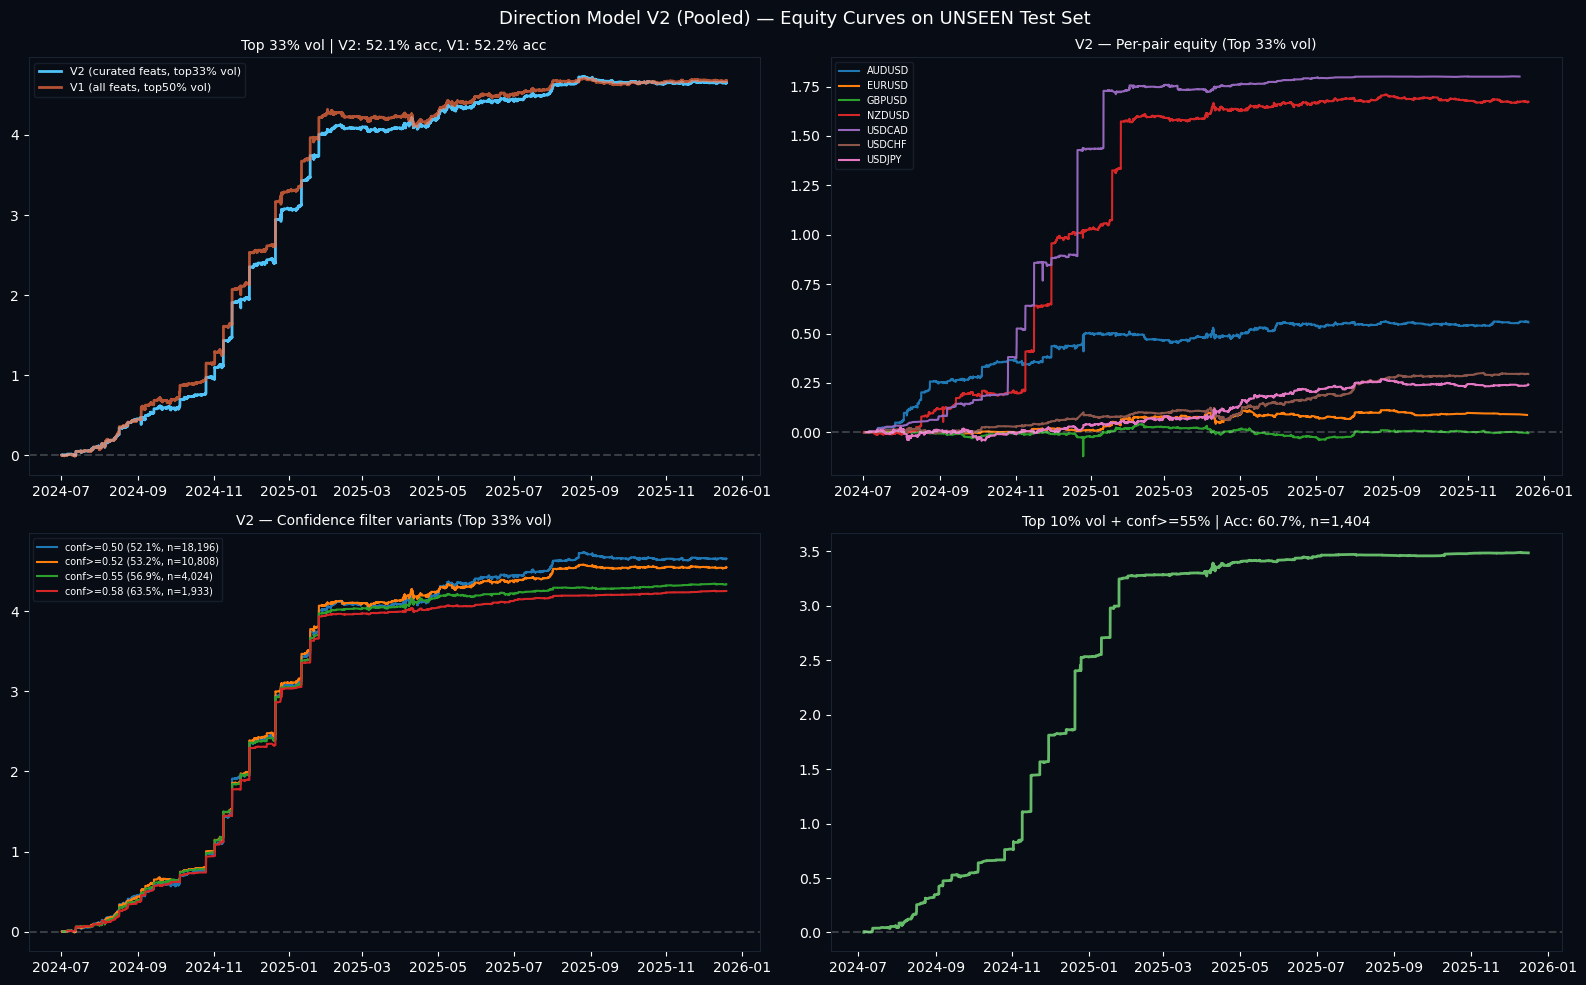

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#080c14')

# Panel 1: V2 vs V1 at Top 33% vol
ax = axes[0, 0]
ax.set_facecolor('#080c14')
vol_mask = results['pred_vol'] > vol_pct[67]
sub = results[vol_mask]
cum_v2 = sub['v2_pnl'].cumsum()
cum_v1 = sub['v1_pnl'].cumsum()
ax.plot(cum_v2.index, cum_v2.values, color='#4fc3f7', linewidth=2, label='V2 (curated feats, top33% vol)')
ax.plot(cum_v1.index, cum_v1.values, color='#ff7043', linewidth=2, alpha=0.7, label='V1 (all feats, top50% vol)')
ax.axhline(0, color='white', alpha=0.2, linestyle='--')
ax.legend(facecolor='#080c14', edgecolor='#1a2332', labelcolor='white', fontsize=8)
v2a = sub['v2_correct'].mean()
v1a = sub['v1_correct'].mean()
ax.set_title(f'Top 33% vol | V2: {v2a:.1%} acc, V1: {v1a:.1%} acc', color='white', fontsize=10)
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

# Panel 2: Per-pair V2 equity curves
ax = axes[0, 1]
ax.set_facecolor('#080c14')
for pair in pairs:
    p = sub[sub['pair'] == pair]
    cum = p['v2_pnl'].cumsum()
    ax.plot(cum.index, cum.values, linewidth=1.5, label=pair)
ax.axhline(0, color='white', alpha=0.2, linestyle='--')
ax.legend(facecolor='#080c14', edgecolor='#1a2332', labelcolor='white', fontsize=7)
ax.set_title('V2 — Per-pair equity (Top 33% vol)', color='white', fontsize=10)
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

# Panel 3: Confidence filter variants
ax = axes[1, 0]
ax.set_facecolor('#080c14')
for conf_thresh in [0.50, 0.52, 0.55, 0.58]:
    mask_c = vol_mask & (results['v2_conf'] >= conf_thresh)
    s = results[mask_c]
    cum = s['v2_pnl'].cumsum()
    acc = s['v2_correct'].mean()
    ax.plot(cum.index, cum.values, linewidth=1.5, label=f'conf>={conf_thresh:.2f} ({acc:.1%}, n={len(s):,})')
ax.axhline(0, color='white', alpha=0.2, linestyle='--')
ax.legend(facecolor='#080c14', edgecolor='#1a2332', labelcolor='white', fontsize=7)
ax.set_title('V2 — Confidence filter variants (Top 33% vol)', color='white', fontsize=10)
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

# Panel 4: Best config — Top 10% vol + high confidence
ax = axes[1, 1]
ax.set_facecolor('#080c14')
mask_best = (results['pred_vol'] > vol_pct[90]) & (results['v2_conf'] >= 0.55)
s_best = results[mask_best]
if len(s_best) > 0:
    cum_best = s_best['v2_pnl'].cumsum()
    acc_best = s_best['v2_correct'].mean()
    ax.plot(cum_best.index, cum_best.values, color='#66bb6a', linewidth=2)
    ax.set_title(f'Top 10% vol + conf>=55% | Acc: {acc_best:.1%}, n={len(s_best):,}', color='white', fontsize=10)
ax.axhline(0, color='white', alpha=0.2, linestyle='--')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

plt.suptitle('Direction Model V2 (Pooled) — Equity Curves on UNSEEN Test Set', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Feature Importance

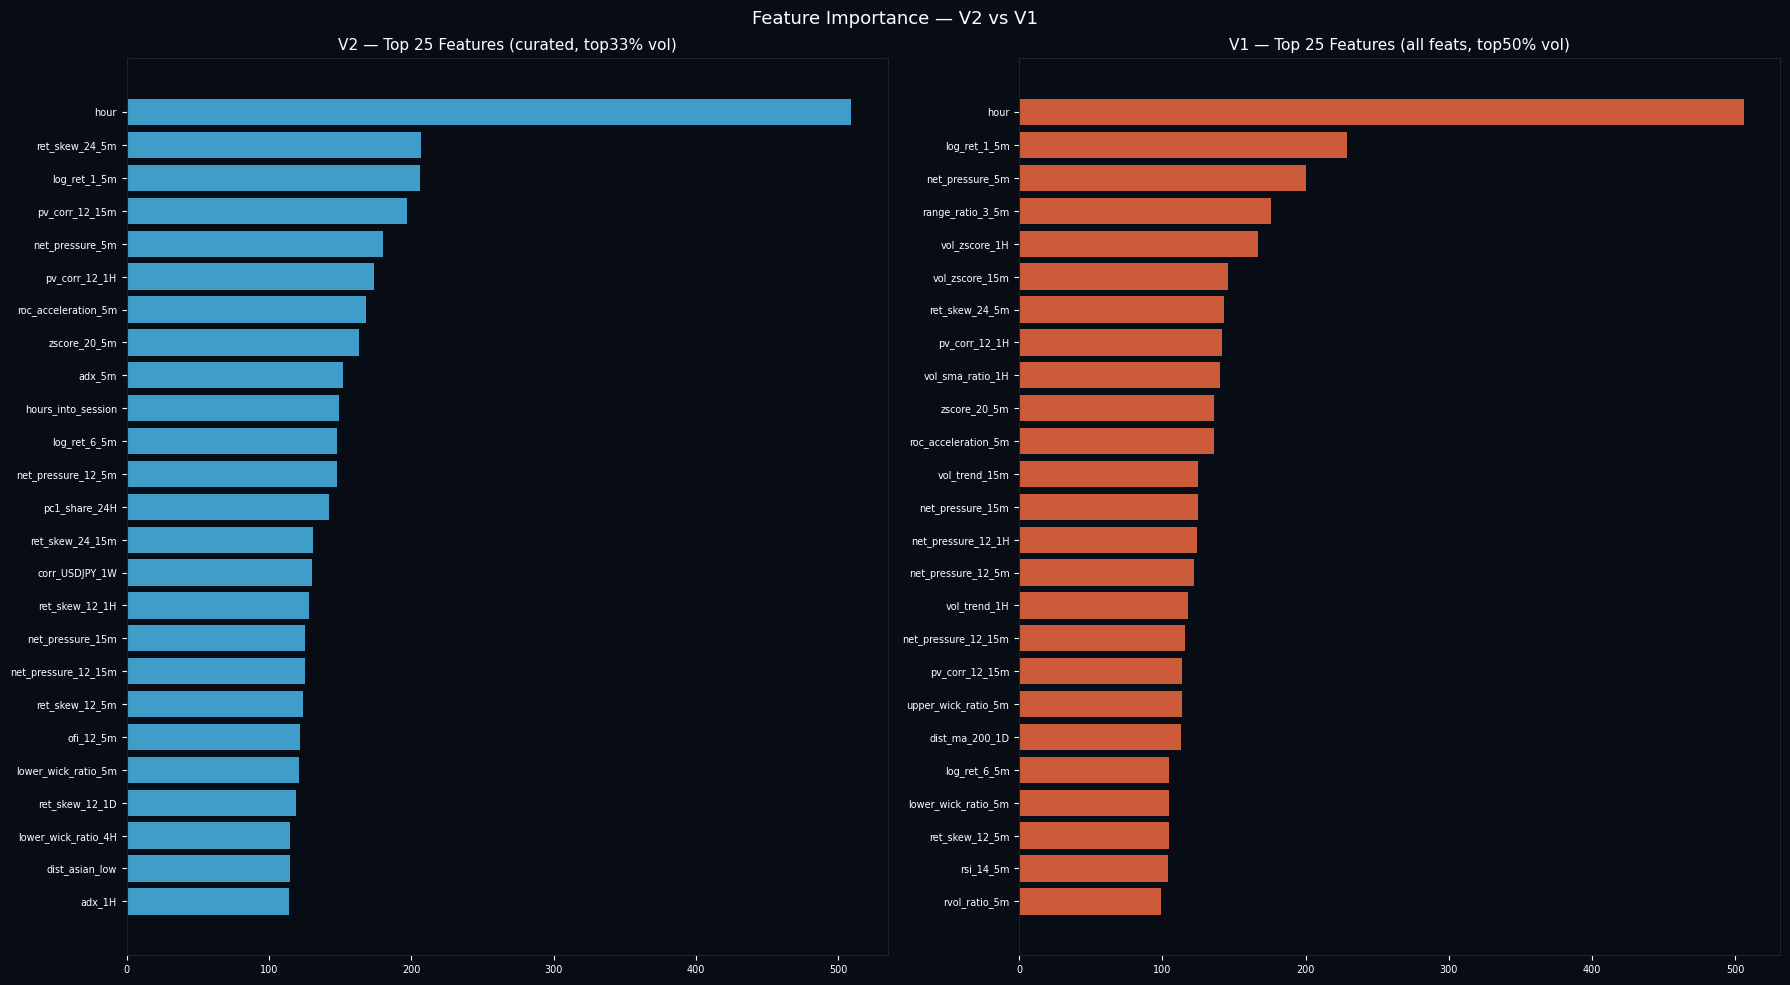

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.patch.set_facecolor('#080c14')

# V2 feature importance
ax = axes[0]
ax.set_facecolor('#080c14')
imp_v2 = pd.Series(final_model.feature_importances_, index=dir_feature_cols)
imp_v2 = imp_v2.sort_values(ascending=True).tail(25)
ax.barh(imp_v2.index, imp_v2.values, color='#4fc3f7', alpha=0.8)
ax.tick_params(colors='white', labelsize=7)
ax.set_title('V2 — Top 25 Features (curated, top33% vol)', color='white', fontsize=11)
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

# V1 feature importance for comparison
ax = axes[1]
ax.set_facecolor('#080c14')
imp_v1 = pd.Series(dir_v1_model.feature_importances_, index=v1_feature_cols)
imp_v1 = imp_v1.sort_values(ascending=True).tail(25)
ax.barh(imp_v1.index, imp_v1.values, color='#ff7043', alpha=0.8)
ax.tick_params(colors='white', labelsize=7)
ax.set_title('V1 — Top 25 Features (all feats, top50% vol)', color='white', fontsize=11)
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

plt.suptitle('Feature Importance — V2 vs V1', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Summary

In [24]:
print('=' * 60)
print('DIRECTION MODEL V2 (POOLED) — TRAINING COMPLETE')
print('=' * 60)

print(f'\nSaved to: {DIR_V2_DIR.resolve()}')
for f in sorted(DIR_V2_DIR.glob('*.joblib')):
    print(f'  {f.name:<30} {f.stat().st_size / 1024 / 1024:.1f} MB')

print(f'\n-- V2 Architecture --')
print(f'  Model: single pooled cross-pair (same as V1)')
print(f'  Features: {len(dir_feature_cols)} direction-curated ({len(dropped)} vol features dropped)')
print(f'  Vol training filter: top {100 - VOL_TRAIN_PERCENTILE}% hours (vs top 50% in V1)')
print(f'  CV Accuracy: {np.mean(fold_accs)*100:.1f}% +/- {np.std(fold_accs)*100:.1f}%')
print(f'  Final model: {avg_iter} iterations')

print(f'\n-- Test Set (UNSEEN: {results.index.min().date()} to {results.index.max().date()}) --')
for name, thresh in [('All hours', 0), ('Top 33%', vol_pct[67]), ('Top 10%', vol_pct[90])]:
    mask = results['pred_vol'] > thresh
    s = results[mask]
    if len(s) < 50:
        continue
    v2_acc = s['v2_correct'].mean()
    v1_acc = s['v1_correct'].mean()
    v2_pnl = s['v2_pnl']
    v1_pnl = s['v1_pnl']
    v2_sh = (v2_pnl.mean() / v2_pnl.std()) * np.sqrt(252*24) if v2_pnl.std() > 0 else 0
    v1_sh = (v1_pnl.mean() / v1_pnl.std()) * np.sqrt(252*24) if v1_pnl.std() > 0 else 0
    delta = (v2_acc - v1_acc) * 100
    print(f'  {name}: V2={v2_acc:.1%} (Sharpe {v2_sh:.2f})  V1={v1_acc:.1%} (Sharpe {v1_sh:.2f})  delta={delta:+.1f}pp')

# Best config
mask_best = (results['pred_vol'] > vol_pct[90]) & (results['v2_conf'] >= 0.55)
s_best = results[mask_best]
if len(s_best) > 50:
    acc_best = s_best['v2_correct'].mean()
    sharpe_best = (s_best['v2_pnl'].mean() / s_best['v2_pnl'].std()) * np.sqrt(252*24)
    print(f'\n  BEST: Top 10% vol + conf>=55%: {acc_best:.1%} acc, Sharpe {sharpe_best:.2f} ({len(s_best):,} trades)')

print(f'\n-- Leakage checklist --')
print(f'  [OK] TRAIN_END = {TRAIN_END} strict temporal split')
print(f'  [OK] Vol threshold from pooled training data P{VOL_TRAIN_PERCENTILE}')
print(f'  [OK] Walk-forward CV within training set only')
print(f'  [OK] No test-set statistics used in training')
print(f'  [OK] Vol model thresholds from vol_model training predictions')

print(f'\n-- Verdict --')
mask_33 = results['pred_vol'] > vol_pct[67]
v2_better = results.loc[mask_33, 'v2_correct'].mean() > results.loc[mask_33, 'v1_correct'].mean()
if v2_better:
    print('  V2 WINS at Top 33% vol — curated features + stricter vol threshold helped!')
else:
    print('  V1 still wins at Top 33% vol — the dropped features were useful for direction too.')
    print('  Consider: keep V1 model, or try other improvements (different target, time conditioning).')

DIRECTION MODEL V2 (POOLED) — TRAINING COMPLETE

Saved to: C:\Users\noual\lumeny\backend\models_4\dir_v2
  dir_v2_per_pair.joblib         2.6 MB
  dir_v2_pooled.joblib           1.9 MB

-- V2 Architecture --
  Model: single pooled cross-pair (same as V1)
  Features: 238 direction-curated (76 vol features dropped)
  Vol training filter: top 33% hours (vs top 50% in V1)
  CV Accuracy: 54.2% +/- 0.5%
  Final model: 344 iterations

-- Test Set (UNSEEN: 2024-07-01 to 2025-12-19) --
  All hours: V2=52.7% (Sharpe 2.85)  V1=53.2% (Sharpe 2.86)  delta=-0.5pp
  Top 33%: V2=52.1% (Sharpe 3.74)  V1=52.2% (Sharpe 3.76)  delta=-0.2pp
  Top 10%: V2=53.1% (Sharpe 6.43)  V1=53.1% (Sharpe 6.82)  delta=+0.0pp

  BEST: Top 10% vol + conf>=55%: 60.7% acc, Sharpe 11.86 (1,404 trades)

-- Leakage checklist --
  [OK] TRAIN_END = 2024-06-30 strict temporal split
  [OK] Vol threshold from pooled training data P67
  [OK] Walk-forward CV within training set only
  [OK] No test-set statistics used in training
  [O